In [ ]:
from google.colab import drive
import pandas as pd

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# -*- coding: utf-8  -*-
from __future__ import print_function
import pandas as pd
import pickle
import os
import numpy as np
import copy

top_n_item_dict_music4all = {10: 56047, 20: 34032, 30: 24758, 40: 19554, 50: 16220}

def generate_data(freq_n_item, top_n_user, min_length, max_length, data, BASE_DIR, DATA_SOURCE, partition):

    # File paths for baseline data
    tr_baseline_user_item_time_record = os.path.join(BASE_DIR, DATA_SOURCE,
        'baseline_tr_freq{}_partition{}.lst'.format(freq_n_item, int(partition*10)))

    te_baseline_user_new_item_time_record = os.path.join(BASE_DIR, DATA_SOURCE,
        'baseline_te_new_freq{}_partition{}.lst'.format(freq_n_item, int(partition*10)))

    # Index mapping file paths
    index2item_path = os.path.join(BASE_DIR, DATA_SOURCE,
        'music4all_music_index2item_freq' + str(freq_n_item) + '_topu' + str(top_n_user))

    item2index_path = os.path.join(BASE_DIR, DATA_SOURCE,
        'music4all_music_item2index_freq' + str(freq_n_item) + '_topu' + str(top_n_user))

    # Open baseline output files
    out_tr_baseline_uit = open(tr_baseline_user_item_time_record, 'w', encoding='utf-8')
    out_tr_baseline_uit.write(str(top_n_user) + ", " + str(top_n_item_dict_music4all[freq_n_item]) + '\n')

    out_te_baseline_new_uit = open(te_baseline_user_new_item_time_record, 'w', encoding='utf-8')

    # Build or load index mappings
    if os.path.exists(index2item_path) and os.path.exists(item2index_path):
        index2item = pickle.load(open(index2item_path, 'rb'))
        item2index = pickle.load(open(item2index_path, 'rb'))
        print('Total music and user %d' % len(index2item))
    else:
        print('Build users index')
        sorted_user_series = data.groupby(['user_id']).size().sort_values(ascending=False)
        user_index2item = sorted_user_series.head(top_n_user).keys().tolist()

        print('Build index2item')
        sorted_item_series = data.groupby(['song_id']).size().sort_values(ascending=False)
        item_index2item = []
        for item_id, count in sorted_item_series.items():
            if count >= freq_n_item:
                item_index2item.append(item_id)
            else:
                break

        albumInfo_file = os.path.join(BASE_DIR, DATA_SOURCE, 'album.csv')
        music2artist_dict = dict()
        music2album_dict = dict()
        artist_list, album_list = [], []

        album_df = pd.read_csv(albumInfo_file)
        item_index2item_set = set(item_index2item)

        for _, row in album_df.iterrows():
            music_id = row.iloc[0]
            artist = row.iloc[1]
            album = row.iloc[2]

            if music_id not in item_index2item_set:
                continue

            if pd.notna(artist):
                music2artist_dict[music_id] = artist
                artist_list.append(artist)

            if pd.notna(album):
                music2album_dict[music_id] = album
                album_list.append(album)

        artist_list = np.unique(artist_list)
        album_list = np.unique(album_list)

        artistID = dict((v, i + len(item_index2item)) for i, v in enumerate(artist_list))
        albumID = dict((v, i + len(item_index2item) + len(artist_list)) for i, v in enumerate(album_list))

        music2artist_res = dict()
        music2album_res = dict()

        music_in_artist_set = set(music2artist_dict.keys())
        music_in_album_set = set(music2album_dict.keys())
        music_noInfo_list = []

        for i, v in enumerate(item_index2item):
            if v not in music_in_artist_set and v not in music_in_album_set:
                music_noInfo_list.append(v)
                music2artist_res[i] = -1
                music2album_res[i] = -1
            elif v not in music_in_artist_set:
                music2artist_res[i] = -1
                music2album_res[i] = albumID[music2album_dict[v]]
            elif v not in music_in_album_set:
                music2artist_res[i] = artistID[music2artist_dict[v]]
                music2album_res[i] = -1
            else:
                music2album_res[i] = albumID[music2album_dict[v]]
                music2artist_res[i] = artistID[music2artist_dict[v]]

        music2artistFile = os.path.join(BASE_DIR, DATA_SOURCE,
            'music4all_music_index2artist_freq' + str(freq_n_item) + '_topu' + str(top_n_user))
        pickle.dump(music2artist_res, open(music2artistFile, 'wb'))

        music2albumFile = os.path.join(BASE_DIR, DATA_SOURCE,
            'music4all_music_index2album_freq' + str(freq_n_item) + '_topu' + str(top_n_user))
        pickle.dump(music2album_res, open(music2albumFile, 'wb'))

        index2item = item_index2item + user_index2item
        item2index = dict((v, i) for i, v in enumerate(index2item))

        pickle.dump(index2item, open(index2item_path, 'wb'))
        pickle.dump(item2index, open(item2index_path, 'wb'))

    print('start loop')
    count = 0
    valid_user_count = 0

    tr_baseline_data = {}
    te_baseline_new_data = {}

    user_group = data.groupby(['user_id'])
    total = len(user_group)

    for user_id, length in user_group.size().sort_values().items():
        if count % 100 == 0:
            print("=====count %d/%d======" % (count, total))
            print('%s %d' % (user_id, length))
        count += 1

        if user_id not in item2index:
            continue

        temp_user_data = user_group.get_group((user_id,)).copy()
        old_time_seq = copy.deepcopy(pd.to_datetime(temp_user_data['timestamp'], format='%Y-%m-%d %H:%M'))
        temp_user_data.loc[:, 'timestamp_new'] = old_time_seq
        user_data = temp_user_data.sort_values(by='timestamp_new')

        music_seq = user_data['song_id']
        music_seq = music_seq[music_seq.notnull()]
        item_seq_list = music_seq.apply(lambda x: (item2index[x]) if pd.notnull(x) and x in item2index else -1).tolist()
        new_item_seq = [item for item in item_seq_list if item != -1]

        if len(new_item_seq) < min_length:
            continue
        else:
            valid_user_count += 1
            user_index = item2index[user_id]
            user_index_baseline = user_index - top_n_item_dict_music4all[freq_n_item]
            pre_index = int(len(new_item_seq) * partition)

            if len(new_item_seq) > max_length:
                new_item_seq = new_item_seq[:max_length]
                pre_index = int(max_length * partition)

            tr_baseline_data[user_index_baseline] = ':'.join(str(x) for x in new_item_seq[:pre_index])
            te_baseline_new_data[user_index_baseline] = ':'.join(str(x) for x in new_item_seq[pre_index:])

    print("valid_user_count is: {}".format(valid_user_count))

    for user_id in sorted(tr_baseline_data.keys(), reverse=True):
        out_tr_baseline_uit.write(str(user_id) + ',' + tr_baseline_data[user_id] + '\n')

    for user_id in sorted(te_baseline_new_data.keys(), reverse=True):
        out_te_baseline_new_uit.write(str(user_id) + ',' + te_baseline_new_data[user_id] + '\n')

    out_tr_baseline_uit.close()
    out_te_baseline_new_uit.close()

if __name__ == '__main__':
    BASE_DIR = '/content/drive/MyDrive/TUGAS_AKHIR/dataset'
    DATA_SOURCE = 'music4all'

    min_length = 200
    max_length = 500
    top_n_user = 8000
    freq_n_item = 10

    path = os.path.join(BASE_DIR, DATA_SOURCE, 'metadata.csv')
    print("start reading csv")

    data = pd.read_csv(path)
    print("finish reading csv")

    partition = 0.8
    print("starting processing for freq_n_item = {}, partition = {}".format(freq_n_item, partition))
    generate_data(freq_n_item, top_n_user, min_length, max_length, data, BASE_DIR, DATA_SOURCE, partition)


start reading csv
finish reading csv
starting processing for freq_n_item = 10, partition = 0.8
Total music and user 64047
start loop
=====count 0/14127======
user_4e4K55C0 3
=====count 100/14127======
user_iTczqUVy 118
=====count 200/14127======
user_0JQJ1feD 151
=====count 300/14127======
user_HZOMUGOv 171
=====count 400/14127======
user_dsjOyRn9 185
=====count 500/14127======
user_lZfoMKW0 198
=====count 600/14127======
user_QvIoJh5K 211
=====count 700/14127======
user_rOEFwsFf 220
=====count 800/14127======
user_fKSznT67 228
=====count 900/14127======
user_intQBTYf 235
=====count 1000/14127======
user_dat2CgVB 243
=====count 1100/14127======
user_RGnyqADG 249
=====count 1200/14127======
user_9J7E4zkE 255
=====count 1300/14127======
user_KsVi5DrJ 261
=====count 1400/14127======
user_k4d9lJdt 265
=====count 1500/14127======
user_z2CBmUJr 270
=====count 1600/14127======
user_FfUKbog1 274
=====count 1700/14127======
user_hg9G3CIW 279
=====count 1800/14127======
user_ICmsspPS 283
=====co

In [ ]:
# -*- coding: utf-8  -*-
from __future__ import print_function
import pandas as pd
import pickle
import os
import numpy as np
import copy

top_n_item_dict_music4all = {10: 56047, 20: 34032, 30: 24758, 40: 19554, 50: 16220}

def generate_data(freq_n_item, top_n_user, min_length, max_length, data, BASE_DIR, DATA_SOURCE, partition):
    tr_baseline_user_item_time_record = os.path.join(BASE_DIR, DATA_SOURCE,
        'baseline_tr_freq{}_partition{}.lst'.format(freq_n_item, int(partition*10)))
    te_baseline_user_new_item_time_record = os.path.join(BASE_DIR, DATA_SOURCE,
        'baseline_te_new_freq{}_partition{}.lst'.format(freq_n_item, int(partition*10)))

    index2item_path = os.path.join(BASE_DIR, DATA_SOURCE,
        'music4all_music_index2item_freq' + str(freq_n_item) + '_topu' + str(top_n_user))
    item2index_path = os.path.join(BASE_DIR, DATA_SOURCE,
        'music4all_music_item2index_freq' + str(freq_n_item) + '_topu' + str(top_n_user))

    out_tr_baseline_uit = open(tr_baseline_user_item_time_record, 'w', encoding='utf-8')
    out_tr_baseline_uit.write(str(top_n_user) + ", " + str(top_n_item_dict_music4all[freq_n_item]) + '\n')
    out_te_baseline_new_uit = open(te_baseline_user_new_item_time_record, 'w', encoding='utf-8')

    if os.path.exists(index2item_path) and os.path.exists(item2index_path):
        index2item = pickle.load(open(index2item_path, 'rb'))
        item2index = pickle.load(open(item2index_path, 'rb'))
        print('Total music and user %d' % len(index2item))
    else:
        print('Build users index')
        sorted_user_series = data.groupby(['user_id']).size().sort_values(ascending=False)
        user_index2item = sorted_user_series.head(top_n_user).keys().tolist()

        print('Build index2item')
        sorted_item_series = data.groupby(['song_id']).size().sort_values(ascending=False)
        item_index2item = []
        for item_id, count in sorted_item_series.items():
            if count >= freq_n_item:
                item_index2item.append(item_id)
            else:
                break

        albumInfo_file = os.path.join(BASE_DIR, DATA_SOURCE, 'album.csv')
        music2artist_dict = dict()
        music2album_dict = dict()
        artist_list, album_list = [], []

        album_df = pd.read_csv(albumInfo_file)
        item_index2item_set = set(item_index2item)

        for _, row in album_df.iterrows():
            music_id = row.iloc[0]
            artist = row.iloc[1]
            album = row.iloc[2]

            if music_id not in item_index2item_set:
                continue

            if pd.notna(artist):
                music2artist_dict[music_id] = artist
                artist_list.append(artist)

            if pd.notna(album):
                music2album_dict[music_id] = album
                album_list.append(album)

        artist_list = np.unique(artist_list)
        album_list = np.unique(album_list)

        artistID = dict((v, i + len(item_index2item)) for i, v in enumerate(artist_list))
        albumID = dict((v, i + len(item_index2item) + len(artist_list)) for i, v in enumerate(album_list))

        music2artist_res = dict()
        music2album_res = dict()
        music_in_artist_set = set(music2artist_dict.keys())
        music_in_album_set = set(music2album_dict.keys())
        music_noInfo_list = []

        for i, v in enumerate(item_index2item):
            if v not in music_in_artist_set and v not in music_in_album_set:
                music_noInfo_list.append(v)
                music2artist_res[i] = -1
                music2album_res[i] = -1
            elif v not in music_in_artist_set:
                music2artist_res[i] = -1
                music2album_res[i] = albumID[music2album_dict[v]]
            elif v not in music_in_album_set:
                music2artist_res[i] = artistID[music2artist_dict[v]]
                music2album_res[i] = -1
            else:
                music2album_res[i] = albumID[music2album_dict[v]]
                music2artist_res[i] = artistID[music2artist_dict[v]]

        music2artistFile = os.path.join(BASE_DIR, DATA_SOURCE,
            'music4all_music_index2artist_freq' + str(freq_n_item) + '_topu' + str(top_n_user))
        pickle.dump(music2artist_res, open(music2artistFile, 'wb'))

        music2albumFile = os.path.join(BASE_DIR, DATA_SOURCE,
            'music4all_music_index2album_freq' + str(freq_n_item) + '_topu' + str(top_n_user))
        pickle.dump(music2album_res, open(music2albumFile, 'wb'))

        index2item = item_index2item + user_index2item
        item2index = dict((v, i) for i, v in enumerate(index2item))

        pickle.dump(index2item, open(index2item_path, 'wb'))
        pickle.dump(item2index, open(item2index_path, 'wb'))

    print('start loop')
    count = 0
    valid_user_count = 0
    tr_baseline_data = {}
    te_baseline_new_data = {}
    invalid_users = []

    user_group = data.groupby(['user_id'])
    total = len(user_group)

    for user_id, length in user_group.size().sort_values().items():
        if count % 100 == 0:
            print("=====count %d/%d======" % (count, total))
            print('%s %d' % (user_id, length))
        count += 1

        if user_id not in item2index:
            continue

        temp_user_data = user_group.get_group((user_id,)).copy()
        old_time_seq = copy.deepcopy(pd.to_datetime(temp_user_data['timestamp'], format='%Y-%m-%d %H:%M'))
        temp_user_data.loc[:, 'timestamp_new'] = old_time_seq
        user_data = temp_user_data.sort_values(by='timestamp_new')

        music_seq = user_data['song_id']
        music_seq = music_seq[music_seq.notnull()]
        item_seq_list = music_seq.apply(lambda x: (item2index[x]) if pd.notnull(x) and x in item2index else -1).tolist()
        new_item_seq = [item for item in item_seq_list if item != -1]

        if len(new_item_seq) < min_length:
            invalid_users.append((user_id, len(new_item_seq)))
            continue
        else:
            valid_user_count += 1
            user_index = item2index[user_id]
            user_index_baseline = user_index - top_n_item_dict_music4all[freq_n_item]
            pre_index = int(len(new_item_seq) * partition)

            if len(new_item_seq) > max_length:
                new_item_seq = new_item_seq[:max_length]
                pre_index = int(max_length * partition)

            tr_baseline_data[user_index_baseline] = ':'.join(str(x) for x in new_item_seq[:pre_index])
            te_baseline_new_data[user_index_baseline] = ':'.join(str(x) for x in new_item_seq[pre_index:])

    print("valid_user_count is: {}".format(valid_user_count))
    print("Total user tidak lolos karena kurang dari min_length ({}): {}".format(min_length, len(invalid_users)))
    print("Daftar user yang tidak lolos:")
    for uid, seq_len in invalid_users:
        print(f"User: {uid}, Length after filtering: {seq_len}")

    # Simpan user tidak lolos ke file
    invalid_users_file = os.path.join(BASE_DIR, DATA_SOURCE, 'invalid_users_minlen.txt')
    with open(invalid_users_file, 'w', encoding='utf-8') as f:
        for uid, seq_len in invalid_users:
            f.write(f"{uid},{seq_len}\n")

    for user_id in sorted(tr_baseline_data.keys(), reverse=True):
        out_tr_baseline_uit.write(str(user_id) + ',' + tr_baseline_data[user_id] + '\n')

    for user_id in sorted(te_baseline_new_data.keys(), reverse=True):
        out_te_baseline_new_uit.write(str(user_id) + ',' + te_baseline_new_data[user_id] + '\n')

    out_tr_baseline_uit.close()
    out_te_baseline_new_uit.close()


if __name__ == '__main__':
    BASE_DIR = '/content/drive/MyDrive/TUGAS_AKHIR/dataset'
    DATA_SOURCE = 'music4all'

    min_length = 200
    max_length = 500
    top_n_user = 8000
    freq_n_item = 10

    path = os.path.join(BASE_DIR, DATA_SOURCE, 'metadata.csv')
    print("start reading csv")

    data = pd.read_csv(path)
    print("finish reading csv")

    partition = 0.8
    print("starting processing for freq_n_item = {}, partition = {}".format(freq_n_item, partition))
    generate_data(freq_n_item, top_n_user, min_length, max_length, data, BASE_DIR, DATA_SOURCE, partition)


start reading csv
finish reading csv
starting processing for freq_n_item = 10, partition = 0.8
Total music and user 64047
start loop
=====count 0/14127======
user_4e4K55C0 3
=====count 100/14127======
user_iTczqUVy 118
=====count 200/14127======
user_0JQJ1feD 151
=====count 300/14127======
user_HZOMUGOv 171
=====count 400/14127======
user_dsjOyRn9 185
=====count 500/14127======
user_lZfoMKW0 198
=====count 600/14127======
user_QvIoJh5K 211
=====count 700/14127======
user_rOEFwsFf 220
=====count 800/14127======
user_fKSznT67 228
=====count 900/14127======
user_intQBTYf 235
=====count 1000/14127======
user_dat2CgVB 243
=====count 1100/14127======
user_RGnyqADG 249
=====count 1200/14127======
user_9J7E4zkE 255
=====count 1300/14127======
user_KsVi5DrJ 261
=====count 1400/14127======
user_k4d9lJdt 265
=====count 1500/14127======
user_z2CBmUJr 270
=====count 1600/14127======
user_FfUKbog1 274
=====count 1700/14127======
user_hg9G3CIW 279
=====count 1800/14127======
user_ICmsspPS 283
=====co

Start reading csv...
Finished reading csv.
Rata-rata panjang sequence: 390.50
Median panjang sequence: 389.0
Panjang maksimum: 500
Panjang minimum: 157


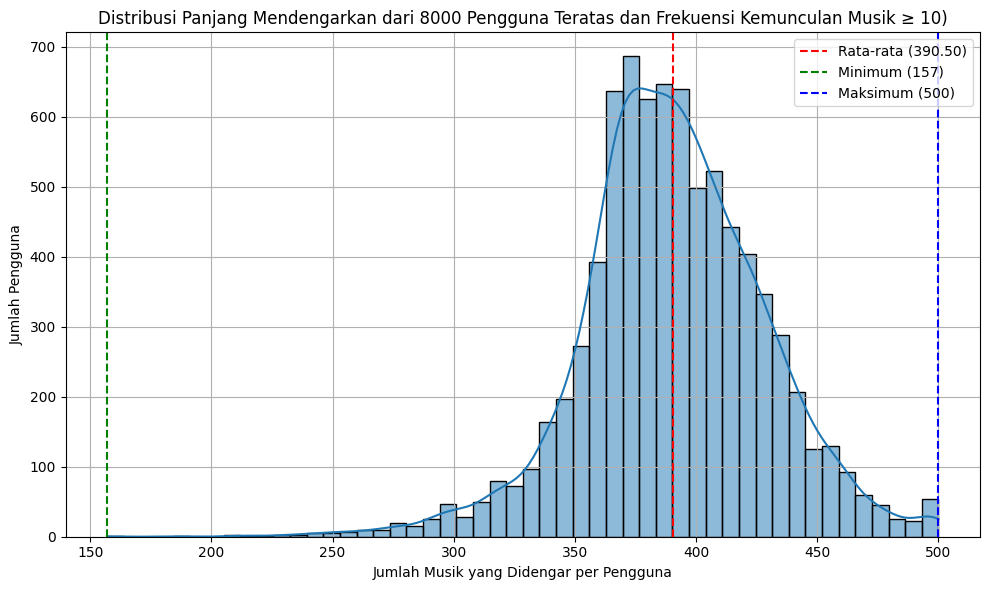

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Path ke dataset
BASE_DIR = '/content/drive/MyDrive/TUGAS_AKHIR/dataset'
DATA_SOURCE = 'music4all'
path = os.path.join(BASE_DIR, DATA_SOURCE, 'metadata.csv')

# Membaca dataset
print("Start reading csv...")
data = pd.read_csv(path)
print("Finished reading csv.")

# Hitung frekuensi lagu
song_freq = data['song_id'].value_counts()

# Filter lagu dengan freq ≥ 10
valid_songs = set(song_freq[song_freq >= 10].index)
data_filtered = data[data['song_id'].isin(valid_songs)]

# Ambil 8000 user teratas dari original data (sebelum filter song)
sorted_user_series = data.groupby(['user_id']).size().sort_values(ascending=False)
user_index2item = sorted_user_series.head(8000).keys().tolist()

# Filter data berdasarkan 8000 user teratas
data_top_users = data_filtered[data_filtered['user_id'].isin(user_index2item)]

# Hitung panjang sequence masing-masing user
user_lengths = data_top_users.groupby('user_id')['song_id'].count()

# Hitung statistik
average_length = user_lengths.mean()
median_length = user_lengths.median()
max_length = user_lengths.max()
min_length = user_lengths.min()

print(f"Rata-rata panjang sequence: {average_length:.2f}")
print(f"Median panjang sequence: {median_length}")
print(f"Panjang maksimum: {max_length}")
print(f"Panjang minimum: {min_length}")

# Visualisasi
plt.figure(figsize=(10, 6))
sns.histplot(user_lengths, bins=50, kde=True)

# Tambahkan garis vertikal
plt.axvline(average_length, color='red', linestyle='--', label=f'Rata-rata ({average_length:.2f})')
plt.axvline(min_length, color='green', linestyle='--', label=f'Minimum ({min_length})')
plt.axvline(max_length, color='blue', linestyle='--', label=f'Maksimum ({max_length})')

plt.title('Distribusi Panjang Mendengarkan dari 8000 Pengguna Teratas dan Frekuensi Kemunculan Musik ≥ 10)')
plt.xlabel('Jumlah Musik yang Didengar per Pengguna')
plt.ylabel('Jumlah Pengguna')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Start reading csv...
Finished reading csv.
Frekuensi ≥ 5: 80735 lagu
Frekuensi ≥ 10: 56047 lagu
Frekuensi ≥ 15: 42416 lagu
Frekuensi ≥ 20: 34032 lagu
Frekuensi ≥ 25: 28596 lagu


/tmp/ipython-input-7-3001538642.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=thresholds, y=num_songs, palette="Blues_d")


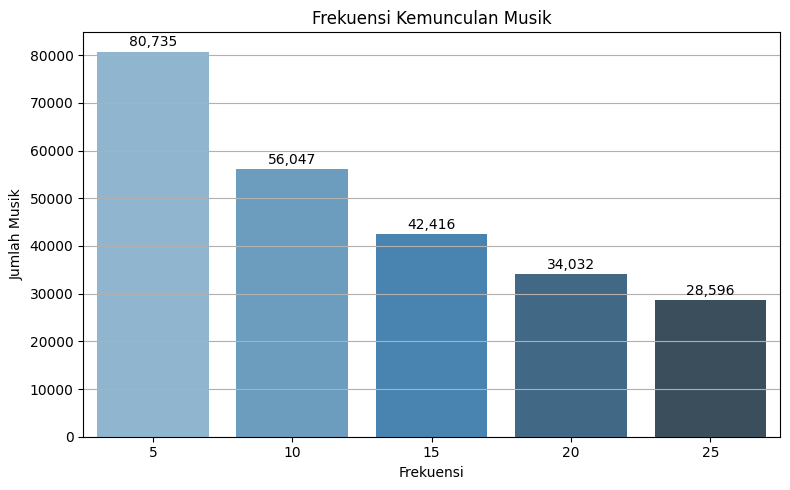

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Path ke dataset
BASE_DIR = '/content/drive/MyDrive/TUGAS_AKHIR/dataset'
DATA_SOURCE = 'music4all'
path = os.path.join(BASE_DIR, DATA_SOURCE, 'metadata.csv')

# Membaca dataset
print("Start reading csv...")
data = pd.read_csv(path)
print("Finished reading csv.")

# Hitung frekuensi kemunculan setiap lagu
song_freq = data['song_id'].value_counts()

# Threshold yang ingin divisualisasikan
thresholds = [5, 10, 15, 20, 25]
num_songs = [(song_freq >= t).sum() for t in thresholds]

# Print jumlah lagunya
for t, n in zip(thresholds, num_songs):
    print(f"Frekuensi ≥ {t}: {n} lagu")

# Plot
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=thresholds, y=num_songs, palette="Blues_d")

# Tambahkan label di atas setiap bar
for i, v in enumerate(num_songs):
    ax.text(i, v + 500, f"{v:,}", ha='center', va='bottom', fontsize=10)

plt.title("Frekuensi Kemunculan Musik")
plt.xlabel("Frekuensi")
plt.ylabel("Jumlah Musik")
plt.grid(axis='y')
plt.tight_layout()
plt.show()


Start reading csv...
Finished reading csv.
Rata-rata panjang sequence: 393.72
Median panjang sequence: 389.0
Panjang maksimum: 500
Panjang minimum: 346


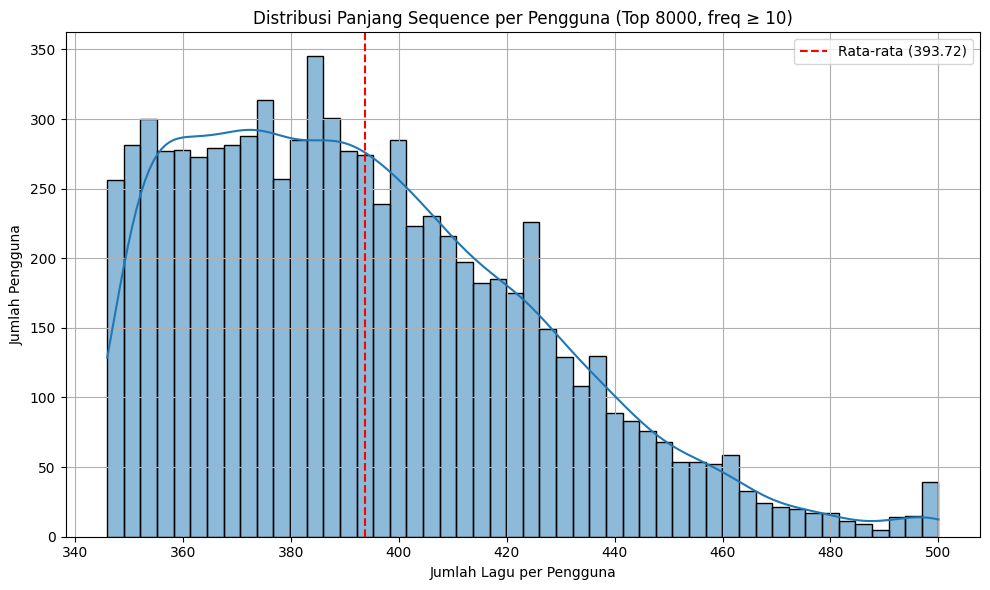

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Path ke dataset
BASE_DIR = '/content/drive/MyDrive/TUGAS_AKHIR/dataset'
DATA_SOURCE = 'music4all'
path = os.path.join(BASE_DIR, DATA_SOURCE, 'metadata.csv')

# Membaca dataset
print("Start reading csv...")
data = pd.read_csv(path)
print("Finished reading csv.")

# Hitung frekuensi lagu
song_freq = data['song_id'].value_counts()

# Ambil hanya lagu dengan freq >= 10
valid_songs = set(song_freq[song_freq >= 10].index)
data_filtered = data[data['song_id'].isin(valid_songs)]

# Ambil 8000 user teratas (paling aktif)
top_users = data_filtered['user_id'].value_counts().head(8000).index
data_filtered = data_filtered[data_filtered['user_id'].isin(top_users)]

# Hitung panjang sequence per user
user_lengths = data_filtered.groupby('user_id')['song_id'].count()

# Hitung statistik rata-rata
average_length = user_lengths.mean()
median_length = user_lengths.median()
max_length = user_lengths.max()
min_length = user_lengths.min()

print(f"Rata-rata panjang sequence: {average_length:.2f}")
print(f"Median panjang sequence: {median_length}")
print(f"Panjang maksimum: {max_length}")
print(f"Panjang minimum: {min_length}")

# Visualisasi distribusi panjang sequence
plt.figure(figsize=(10, 6))
sns.histplot(user_lengths, bins=50, kde=True)
plt.axvline(average_length, color='red', linestyle='--', label=f'Rata-rata ({average_length:.2f})')
plt.title('Distribusi Panjang Sequence per Pengguna (Top 8000, freq ≥ 10)')
plt.xlabel('Jumlah Lagu per Pengguna')
plt.ylabel('Jumlah Pengguna')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import pickle

# Sesuaikan path ke file pickle kamu
index2item_path = '/content/drive/MyDrive/TUGAS_AKHIR/dataset/music4all/music4all_music_index2item_freq10_topu8000'

# Load index2item
with open(index2item_path, 'rb') as f:
    index2item = pickle.load(f)

# Konversi user index ke posisi dalam index2item
top_n_item = 56047  # dari top_n_item_dict_music4all[10]
user_index = 7993
user_position = top_n_item + user_index

# Dapatkan user_id asli
user_id_asli = index2item[user_position]
print("User index 7993 adalah user_id asli:", user_id_asli)


User index 7993 adalah user_id asli: user_fyyOtukQ


In [ ]:
import pandas as pd
import pickle

# Load file index2item
index2item_path = '/content/drive/MyDrive/TUGAS_AKHIR/dataset/music4all/music4all_music_index2item_freq10_topu8000'
with open(index2item_path, 'rb') as f:
    index2item = pickle.load(f)

# Hitung posisi user_index ke dalam list index2item
top_n_item = 56047  # dari top_n_item_dict_music4all[10]
user_index = 7993
user_position = top_n_item + user_index

# Ambil user_id asli dari mapping
user_id_asli = index2item[user_position]
print("User index 7993 adalah user_id asli:", user_id_asli)

# Load metadata
metadata_path = '/content/drive/MyDrive/TUGAS_AKHIR/dataset/music4all/metadata.csv'
data = pd.read_csv(metadata_path)

# Filter semua baris dan kolom untuk user tersebut
user_data = data[data['user_id'] == user_id_asli]

# Tampilkan seluruh baris dan kolom untuk user_id tersebut
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

print(user_data)


User index 7993 adalah user_id asli: user_fyyOtukQ
               user_id           song_id         timestamp  \
3455504  user_fyyOtukQ  cU7wXxFv0vUJTZwr  2019-02-20 17:08   
3455505  user_fyyOtukQ  iioxNHQSzVB0cAz4  2019-02-20 17:12   
3455506  user_fyyOtukQ  3G6YdquxUGPnpubQ  2019-02-20 17:15   
3455507  user_fyyOtukQ  rysmxYZVR1Z4i0Xy  2019-02-20 17:21   
3455508  user_fyyOtukQ  h4FVkBtXFDQSrlbX  2019-02-20 17:23   
3455509  user_fyyOtukQ  D3bTn3ZNBGoZ2fV1  2019-02-20 17:27   
3455510  user_fyyOtukQ  AkGyrviNXUf9Hh2h  2019-02-20 17:30   
3455511  user_fyyOtukQ  oRZYfgzxewAp6Rgl  2019-02-20 17:34   
3455512  user_fyyOtukQ  K1hw31Txu8QtXGbc  2019-02-20 17:37   
3455513  user_fyyOtukQ  7kVURZXnP9Qtb7Ib  2019-02-20 17:44   
3455514  user_fyyOtukQ  p5ywwKVV4r0Nz1WA  2019-02-20 17:49   
3455515  user_fyyOtukQ  1eApBsTMCYUAWWKW  2019-02-20 17:53   
3455516  user_fyyOtukQ  KKmk2QJLVj2Aqsjg  2019-02-20 21:01   
3455517  user_fyyOtukQ  3shrACNQQ5eeQEAO  2019-02-20 21:04   
3455518  user_fyyOt

In [ ]:
import pickle

# Path ke file mapping item2index
item2index_path = '/content/drive/MyDrive/TUGAS_AKHIR/dataset/music4all/music4all_music_item2index_freq10_topu8000'

# Load dictionary item2index
with open(item2index_path, 'rb') as f:
    item2index = pickle.load(f)

# Cari indeks untuk song_id yang dimaksud
song_id = 'cU7wXxFv0vUJTZwr'

if song_id in item2index:
    index_lagu = item2index[song_id]
    print(f"song_id '{song_id}' ada di index ke-{index_lagu}")
else:
    print(f"song_id '{song_id}' tidak ditemukan dalam item2index")


song_id 'cU7wXxFv0vUJTZwr' ada di index ke-20


In [ ]:
train_tanpa_s = '/content/baseline_tr_freq10_partition8 (14).lst'
train_dengan_s = '/content/baseline_tr_freq10_partition8.lst'

def compare_train_files_per_item(path1, path2):
    with open(path1, 'r', encoding='utf-8') as f1, open(path2, 'r', encoding='utf-8') as f2:
        lines1 = f1.readlines()[1:]  # Skip header
        lines2 = f2.readlines()[1:]  # Skip header

    total = len(lines1)
    same_count = 0
    diff_details = []

    for i, (line1, line2) in enumerate(zip(lines1, lines2)):
        user1, items1 = line1.strip().split(',', 1)
        user2, items2 = line2.strip().split(',', 1)

        if user1 != user2:
            diff_details.append((i, user1, user2, 'User ID mismatch'))
            continue

        seq1 = items1.split(':')
        seq2 = items2.split(':')

        if seq1 == seq2:
            same_count += 1
        else:
            # Hitung selisih item
            min_len = min(len(seq1), len(seq2))
            mismatch_idx = [j for j in range(min_len) if seq1[j] != seq2[j]]
            extra1 = seq1[min_len:]
            extra2 = seq2[min_len:]

            diff_details.append({
                'line': i + 2,
                'user_index': user1,
                'total_items_1': len(seq1),
                'total_items_2': len(seq2),
                'mismatch_indices': mismatch_idx,
                'item_mismatches': [(seq1[j], seq2[j]) for j in mismatch_idx],
                'extra_in_1': extra1,
                'extra_in_2': extra2
            })

    print(f"📊 Total user dibandingkan: {total}")
    print(f"✅ Sama persis: {same_count}")
    print(f"❌ Berbeda   : {total - same_count}")

    if diff_details:
        print("\n🔍 Contoh perbedaan detail (maks. 3):")
        for detail in diff_details[:3]:
            print(f"\nBaris ke-{detail['line']} (user_index: {detail['user_index']}):")
            print(f"  Jumlah item file 1: {detail['total_items_1']}")
            print(f"  Jumlah item file 2: {detail['total_items_2']}")
            print(f"  Posisi mismatch   : {detail['mismatch_indices']}")
            print(f"  Item mismatch     : {detail['item_mismatches']}")
            if detail['extra_in_1']:
                print(f"  Extra di file 1   : {detail['extra_in_1']}")
            if detail['extra_in_2']:
                print(f"  Extra di file 2   : {detail['extra_in_2']}")

# Jalankan
compare_train_files_per_item(train_tanpa_s, train_dengan_s)


📊 Total user dibandingkan: 7998
✅ Sama persis: 4663
❌ Berbeda   : 3335

🔍 Contoh perbedaan detail (maks. 3):

Baris ke-8 (user_index: 7993):
  Jumlah item file 1: 288
  Jumlah item file 2: 288
  Posisi mismatch   : [286, 287]
  Item mismatch     : [('0', '70'), ('4013', '60')]

Baris ke-10 (user_index: 7991):
  Jumlah item file 1: 269
  Jumlah item file 2: 269
  Posisi mismatch   : [132, 133, 134, 135, 136, 137, 138, 139, 146, 147, 148, 150, 151, 152, 153, 241, 242]
  Item mismatch     : [('1095', '441'), ('739', '804'), ('258', '724'), ('148', '168'), ('804', '148'), ('724', '258'), ('441', '739'), ('168', '1095'), ('40000', '7318'), ('532', '1894'), ('4483', '146'), ('614', '4483'), ('146', '532'), ('1894', '40000'), ('7318', '614'), ('11060', '1782'), ('1782', '11060')]

Baris ke-17 (user_index: 7984):
  Jumlah item file 1: 291
  Jumlah item file 2: 291
  Posisi mismatch   : [101, 102, 181, 182]
  Item mismatch     : [('5942', '3644'), ('3644', '5942'), ('8045', '9188'), ('9188', '8

In [ ]:
train_tanpa_s = '/content/baseline_te_new_freq10_partition8 (26).lst'
train_dengan_s = '/content/baseline_te_new_freq10_partition8.lst'


def compare_train_files_per_item(path1, path2):
    with open(path1, 'r', encoding='utf-8') as f1, open(path2, 'r', encoding='utf-8') as f2:
        lines1 = f1.readlines()[1:]  # Skip header
        lines2 = f2.readlines()[1:]  # Skip header

    total = len(lines1)
    same_count = 0
    diff_details = []

    for i, (line1, line2) in enumerate(zip(lines1, lines2)):
        user1, items1 = line1.strip().split(',', 1)
        user2, items2 = line2.strip().split(',', 1)

        if user1 != user2:
            diff_details.append((i, user1, user2, 'User ID mismatch'))
            continue

        seq1 = items1.split(':')
        seq2 = items2.split(':')

        if seq1 == seq2:
            same_count += 1
        else:
            # Hitung selisih item
            min_len = min(len(seq1), len(seq2))
            mismatch_idx = [j for j in range(min_len) if seq1[j] != seq2[j]]
            extra1 = seq1[min_len:]
            extra2 = seq2[min_len:]

            diff_details.append({
                'line': i + 2,
                'user_index': user1,
                'total_items_1': len(seq1),
                'total_items_2': len(seq2),
                'mismatch_indices': mismatch_idx,
                'item_mismatches': [(seq1[j], seq2[j]) for j in mismatch_idx],
                'extra_in_1': extra1,
                'extra_in_2': extra2
            })

    print(f"📊 Total user dibandingkan: {total}")
    print(f"✅ Sama persis: {same_count}")
    print(f"❌ Berbeda   : {total - same_count}")

    if diff_details:
        print("\n🔍 Contoh perbedaan detail (maks. 3):")
        for detail in diff_details[:3]:
            print(f"\nBaris ke-{detail['line']} (user_index: {detail['user_index']}):")
            print(f"  Jumlah item file 1: {detail['total_items_1']}")
            print(f"  Jumlah item file 2: {detail['total_items_2']}")
            print(f"  Posisi mismatch   : {detail['mismatch_indices']}")
            print(f"  Item mismatch     : {detail['item_mismatches']}")
            if detail['extra_in_1']:
                print(f"  Extra di file 1   : {detail['extra_in_1']}")
            if detail['extra_in_2']:
                print(f"  Extra di file 2   : {detail['extra_in_2']}")

# Jalankan
compare_train_files_per_item(train_tanpa_s, train_dengan_s)



📊 Total user dibandingkan: 7997
✅ Sama persis: 6719
❌ Berbeda   : 1278

🔍 Contoh perbedaan detail (maks. 3):

Baris ke-7 (user_index: 7993):
  Jumlah item file 1: 72
  Jumlah item file 2: 72
  Posisi mismatch   : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
  Item mismatch     : [('2158', '5'), ('193', '1561'), ('9931', '5758'), ('242', '1207'), ('115', '242'), ('5758', '9931'), ('1561', '193'), ('1207', '115'), ('5', '2158'), ('60', '4013'), ('70', '0')]

Baris ke-9 (user_index: 7991):
  Jumlah item file 1: 68
  Jumlah item file 2: 68
  Posisi mismatch   : [10, 11, 12, 13, 15, 16, 17, 18]
  Item mismatch     : [('9054', '16010'), ('29697', '532'), ('2736', '11385'), ('5439', '29868'), ('29868', '5439'), ('11385', '2736'), ('532', '29697'), ('16010', '9054')]

Baris ke-15 (user_index: 7985):
  Jumlah item file 1: 71
  Jumlah item file 2: 71
  Posisi mismatch   : [5, 6]
  Item mismatch     : [('138', '236'), ('236', '138')]


In [ ]:
# -*- coding: utf-8  -*-
from __future__ import print_function
import pandas as pd
import pickle
import os
import numpy as np
import copy

top_n_item_dict_music4all = {10: 56047, 20: 34032, 30: 24758, 40: 19554, 50: 16220}

def generate_data(freq_n_item, top_n_user, min_length, max_length, data, BASE_DIR, DATA_SOURCE, train_ratio=0.6, valid_ratio=0.2):
    # Calculate test ratio for clarity
    test_ratio = 1 - train_ratio - valid_ratio

    # File paths for baseline data
    tr_baseline_user_item_time_record = os.path.join(BASE_DIR, DATA_SOURCE,
        'baseline_tr_freq{}_train{}.lst'.format(freq_n_item, int(train_ratio*10)))

    val_baseline_user_item_time_record = os.path.join(BASE_DIR, DATA_SOURCE,
        'baseline_val_freq{}_valid{}.lst'.format(freq_n_item, int(valid_ratio*10)))

    te_baseline_user_new_item_time_record = os.path.join(BASE_DIR, DATA_SOURCE,
        'baseline_te_new_freq{}_test{}.lst'.format(freq_n_item, int(test_ratio*10)))

    # Index mapping file paths
    index2item_path = os.path.join(BASE_DIR, DATA_SOURCE,
        'music4all_music_index2item_freq' + str(freq_n_item) + '_topu' + str(top_n_user))

    item2index_path = os.path.join(BASE_DIR, DATA_SOURCE,
        'music4all_music_item2index_freq' + str(freq_n_item) + '_topu' + str(top_n_user))

    # Open baseline output files
    out_tr_baseline_uit = open(tr_baseline_user_item_time_record, 'w', encoding='utf-8')
    out_tr_baseline_uit.write(str(top_n_user) + ", " + str(top_n_item_dict_music4all[freq_n_item]) + '\n')
    out_val_baseline_uit = open(val_baseline_user_item_time_record, 'w', encoding='utf-8')
    out_te_baseline_new_uit = open(te_baseline_user_new_item_time_record, 'w', encoding='utf-8')

    # Build or load index mappings
    if os.path.exists(index2item_path) and os.path.exists(item2index_path):
        index2item = pickle.load(open(index2item_path, 'rb'))
        item2index = pickle.load(open(item2index_path, 'rb'))
        print('Total music and user %d' % len(index2item))
    else:
        print('Build users index')
        sorted_user_series = data.groupby(['user_id']).size().sort_values(ascending=False)
        user_index2item = sorted_user_series.head(top_n_user).keys().tolist()

        print('Build index2item')
        sorted_item_series = data.groupby(['song_id']).size().sort_values(ascending=False)
        item_index2item = []
        for item_id, count in sorted_item_series.items():
            if count >= freq_n_item:
                item_index2item.append(item_id)
            else:
                break

        albumInfo_file = os.path.join(BASE_DIR, DATA_SOURCE, 'album.csv')
        music2artist_dict = dict()
        music2album_dict = dict()
        artist_list, album_list = [], []

        album_df = pd.read_csv(albumInfo_file)
        item_index2item_set = set(item_index2item)

        for _, row in album_df.iterrows():
            music_id = row.iloc[0]
            artist = row.iloc[1]
            album = row.iloc[2]

            if music_id not in item_index2item_set:
                continue

            if pd.notna(artist):
                music2artist_dict[music_id] = artist
                artist_list.append(artist)

            if pd.notna(album):
                music2album_dict[music_id] = album
                album_list.append(album)

        artist_list = np.unique(artist_list)
        album_list = np.unique(album_list)

        artistID = dict((v, i + len(item_index2item)) for i, v in enumerate(artist_list))
        albumID = dict((v, i + len(item_index2item) + len(artist_list)) for i, v in enumerate(album_list))

        music2artist_res = dict()
        music2album_res = dict()

        music_in_artist_set = set(music2artist_dict.keys())
        music_in_album_set = set(music2album_dict.keys())
        music_noInfo_list = []

        for i, v in enumerate(item_index2item):
            if v not in music_in_artist_set and v not in music_in_album_set:
                music_noInfo_list.append(v)
                music2artist_res[i] = -1
                music2album_res[i] = -1
            elif v not in music_in_artist_set:
                music2artist_res[i] = -1
                music2album_res[i] = albumID[music2album_dict[v]]
            elif v not in music_in_album_set:
                music2artist_res[i] = artistID[music2artist_dict[v]]
                music2album_res[i] = -1
            else:
                music2album_res[i] = albumID[music2album_dict[v]]
                music2artist_res[i] = artistID[music2artist_dict[v]]

        music2artistFile = os.path.join(BASE_DIR, DATA_SOURCE,
            'music4all_music_index2artist_freq' + str(freq_n_item) + '_topu' + str(top_n_user))
        pickle.dump(music2artist_res, open(music2artistFile, 'wb'))

        music2albumFile = os.path.join(BASE_DIR, DATA_SOURCE,
            'music4all_music_index2album_freq' + str(freq_n_item) + '_topu' + str(top_n_user))
        pickle.dump(music2album_res, open(music2albumFile, 'wb'))

        index2item = item_index2item + user_index2item
        item2index = dict((v, i) for i, v in enumerate(index2item))

        pickle.dump(index2item, open(index2item_path, 'wb'))
        pickle.dump(item2index, open(item2index_path, 'wb'))

    print('start loop')
    count = 0
    valid_user_count = 0

    tr_baseline_data = {}
    val_baseline_data = {}  # New dictionary for validation data
    te_baseline_new_data = {}

    user_group = data.groupby(['user_id'])
    total = len(user_group)

    for user_id, length in user_group.size().sort_values().items():
        if count % 100 == 0:
            print("=====count %d/%d======" % (count, total))
            print('%s %d' % (user_id, length))
        count += 1

        if user_id not in item2index:
            continue

        temp_user_data = user_group.get_group((user_id,)).copy()
        old_time_seq = copy.deepcopy(pd.to_datetime(temp_user_data['timestamp'], format='%Y-%m-%d %H:%M'))
        temp_user_data.loc[:, 'timestamp_new'] = old_time_seq
        user_data = temp_user_data.sort_values(by='timestamp_new')

        music_seq = user_data['song_id']
        music_seq = music_seq[music_seq.notnull()]
        item_seq_list = music_seq.apply(lambda x: (item2index[x]) if pd.notnull(x) and x in item2index else -1).tolist()
        new_item_seq = [item for item in item_seq_list if item != -1]

        if len(new_item_seq) < min_length:
            continue
        else:
            valid_user_count += 1
            user_index = item2index[user_id]
            user_index_baseline = user_index - top_n_item_dict_music4all[freq_n_item]

            # If sequence is too long, truncate it
            if len(new_item_seq) > max_length:
                new_item_seq = new_item_seq[:max_length]

            # Calculate split points for 60/20/20 division
            train_end = int(len(new_item_seq) * train_ratio)
            valid_end = int(len(new_item_seq) * (train_ratio + valid_ratio))

            # Split the sequence into three parts
            train_seq = new_item_seq[:train_end]
            valid_seq = new_item_seq[train_end:valid_end]
            test_seq = new_item_seq[valid_end:]

            # Store the three parts
            tr_baseline_data[user_index_baseline] = ':'.join(str(x) for x in train_seq)
            val_baseline_data[user_index_baseline] = ':'.join(str(x) for x in valid_seq)
            te_baseline_new_data[user_index_baseline] = ':'.join(str(x) for x in test_seq)

    print("valid_user_count is: {}".format(valid_user_count))
    print(f"Data split: {train_ratio*100}% training, {valid_ratio*100}% validation, {test_ratio*100}% testing")

    # Write training data
    for user_id in sorted(tr_baseline_data.keys(), reverse=True):
        out_tr_baseline_uit.write(str(user_id) + ',' + tr_baseline_data[user_id] + '\n')

    # Write validation data
    for user_id in sorted(val_baseline_data.keys(), reverse=True):
        out_val_baseline_uit.write(str(user_id) + ',' + val_baseline_data[user_id] + '\n')

    # Write testing data
    for user_id in sorted(te_baseline_new_data.keys(), reverse=True):
        out_te_baseline_new_uit.write(str(user_id) + ',' + te_baseline_new_data[user_id] + '\n')

    # Close all files
    out_tr_baseline_uit.close()
    out_val_baseline_uit.close()
    out_te_baseline_new_uit.close()

    print(f"Successfully generated train/validation/test data with {train_ratio}/{valid_ratio}/{test_ratio} split")

if __name__ == '__main__':
    BASE_DIR = '/content/drive/MyDrive/TUGAS_AKHIR/dataset'
    DATA_SOURCE = 'music4all'

    min_length = 200
    max_length = 500
    top_n_user = 8000
    freq_n_item = 10

    path = os.path.join(BASE_DIR, DATA_SOURCE, 'metadata.csv')
    print("start reading csv")

    data = pd.read_csv(path)
    print("finish reading csv")

    # Use 60/20/20 split instead of the original 80/20
    train_ratio = 0.6
    valid_ratio = 0.2
    # test_ratio = 0.2 (implicitly calculated as 1 - train_ratio - valid_ratio)

    print(f"Starting processing for freq_n_item = {freq_n_item}")
    print(f"Using data split: {train_ratio*100}% training, {valid_ratio*100}% validation, {(1-train_ratio-valid_ratio)*100}% testing")

    generate_data(freq_n_item, top_n_user, min_length, max_length, data, BASE_DIR, DATA_SOURCE,
                 train_ratio=train_ratio, valid_ratio=valid_ratio)

start reading csv
finish reading csv
Starting processing for freq_n_item = 10
Using data split: 60.0% training, 20.0% validation, 20.0% testing
Total music and user 64047
start loop
=====count 0/14127======
user_4e4K55C0 3
=====count 100/14127======
user_iTczqUVy 118
=====count 200/14127======
user_0JQJ1feD 151
=====count 300/14127======
user_HZOMUGOv 171
=====count 400/14127======
user_dsjOyRn9 185
=====count 500/14127======
user_lZfoMKW0 198
=====count 600/14127======
user_QvIoJh5K 211
=====count 700/14127======
user_rOEFwsFf 220
=====count 800/14127======
user_fKSznT67 228
=====count 900/14127======
user_intQBTYf 235
=====count 1000/14127======
user_dat2CgVB 243
=====count 1100/14127======
user_RGnyqADG 249
=====count 1200/14127======
user_9J7E4zkE 255
=====count 1300/14127======
user_KsVi5DrJ 261
=====count 1400/14127======
user_k4d9lJdt 265
=====count 1500/14127======
user_z2CBmUJr 270
=====count 1600/14127======
user_FfUKbog1 274
=====count 1700/14127======
user_hg9G3CIW 279
====